# Análise Exploratória Inicial — Discursos dos Presidentes do Brasil

Este notebook inaugura o projeto **Brazil Presidents' Speeches Analysis**. O objetivo aqui é **carregar os dados**, **entender sua estrutura** e realizar uma **análise exploratória básica (EDA)** sobre os discursos.

## Configuração Inicial:

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

from matplotlib.pyplot import yticks
from sqlalchemy import create_engine
from dotenv import load_dotenv

load_dotenv()

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)

## Carregando discursos:

In [40]:
query = """
SELECT presidente, n_par, par
FROM speeches;
"""

df = pd.read_sql(query, engine)
df.head()

,presidente,n_par,par
0,Marechal Deodoro da Fonseca,1,"Concidadãos – O povo, o exército e a armada na..."
1,Marechal Deodoro da Fonseca,2,Como resultado imediato desta revolução nacion...
2,Marechal Deodoro da Fonseca,3,"Para comporem esse governo, enquanto a nação s..."
3,Marechal Deodoro da Fonseca,4,"Concidadãos – O governo provisório, simples ag..."
4,Marechal Deodoro da Fonseca,5,No uso das atribuições e faculdades extraordin...


## Visão geral do dataset:

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   presidente  1540 non-null   object
 1   n_par       1540 non-null   int64 
 2   par         1540 non-null   object
dtypes: int64(1), object(2)
memory usage: 36.2+ KB


## Discursos mais longos:

In [42]:
query = """
SELECT presidente, count(*) AS total_palavras
FROM (
         SELECT presidente,
             n_par,
             unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúàèìòùâêîôûãõçü ]', '', 'g')), ' ')) AS palavra
         FROM speeches
) AS t
WHERE palavra != ''
GROUP BY presidente
ORDER BY total_palavras DESC;
"""

df_tamanho = pd.read_sql(query, engine)
df_tamanho.head(20)

,presidente,total_palavras
0,Fernando Collor de Mello,5859
1,Dilma Rousseff 2,4493
2,Luiz Inácio Lula da Silva 1,3854
3,Dilma Rousseff 1,3715
4,Luiz Inácio Lula da Silva 2,3679
5,Wenceslau Brás,3614
6,Campos Sales,3565
7,Epitácio Pessoa,3548
8,Affonso Pena,3454
9,Getúlio Vargas 2,3435


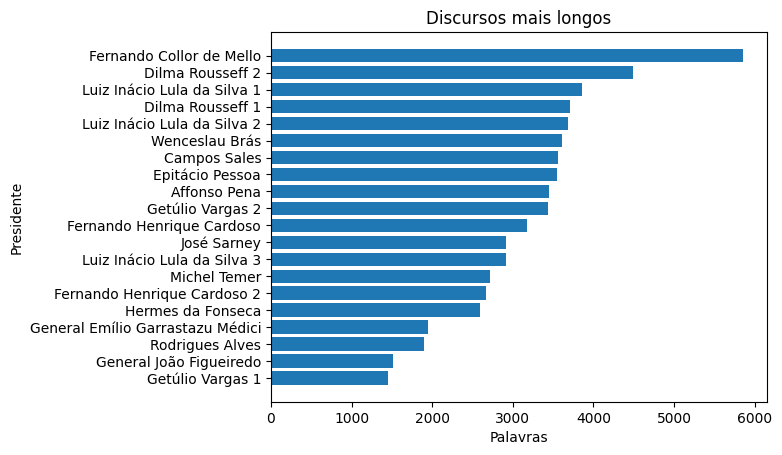

In [43]:
def plot_top_speeches(df, title):
    plt.figure()
    plt.barh(df['presidente'], df['total_palavras'])
    plt.xlabel("Palavras")
    plt.ylabel("Presidente")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

plot_top_speeches(df_tamanho.head(20),"Discursos mais longos")

## Discursos mais curtos:

In [44]:
df_tamanho_inverso = df_tamanho[::-1]
df_tamanho_inverso.head(20)

,presidente,total_palavras
34,Marechal Deodoro da Fonseca,315
33,Washington Luís,417
32,Arthur Bernardes,480
31,Marechal Costa e Silva,563
30,Itamar Franco,602
29,General Ernesto Geisel,618
28,Juscelino Kubitschek,625
27,Jânio Quadros,642
26,Floriano Peixoto,744
25,Eurico Gaspar Dutra,785


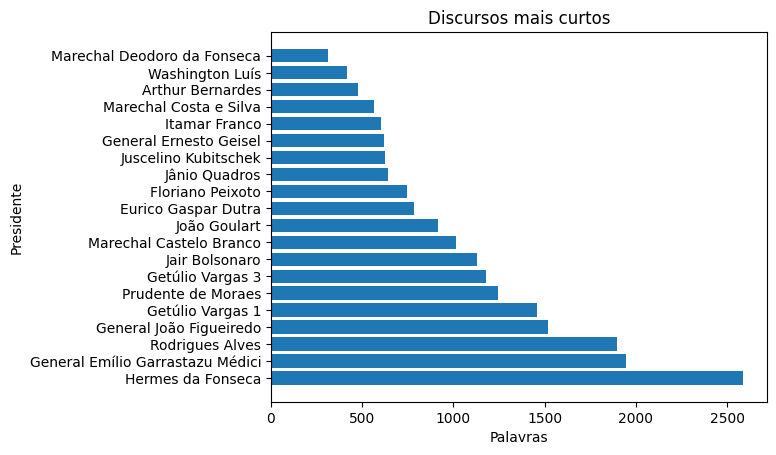

In [45]:
plot_top_speeches(df_tamanho_inverso.head(20),"Discursos mais curtos")

## Palavras mais usadas:

In [46]:
query = """
SELECT palavra, count(*) AS ocur
FROM (
         SELECT presidente,
             n_par,
             unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúàèìòùâêîôûãõçü ]', '', 'g')), ' ')) AS palavra
         FROM speeches
) AS t
WHERE palavra != ''
GROUP BY palavra
ORDER BY ocur DESC;
"""

df_palavras = pd.read_sql(query, engine)
df_palavras.head(10)

,palavra,ocur
0,de,3414
1,e,3106
2,a,2921
3,que,2206
4,o,2052
5,do,1441
6,da,1427
7,para,873
8,os,817
9,em,737


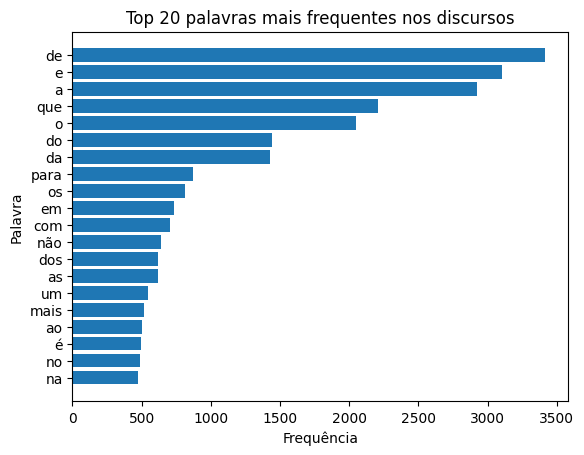

In [47]:
def plot_top_words(df, title):
    plt.figure()
    plt.barh(df['palavra'], df['ocur'])
    plt.xlabel("Frequência")
    plt.ylabel("Palavra")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.show()

df_palavras.head(20)

plot_top_words(df_palavras.head(20),"Top 20 palavras mais frequentes nos discursos")

Após a remoção de stopwords, o corpus foi reduzido principalmente a substantivos, adjetivos, verbos e nomes próprios, permitindo uma análise mais semântica do discurso.

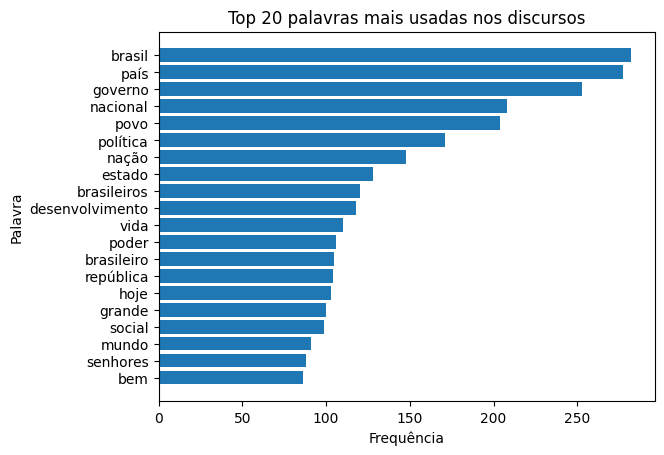

In [48]:
STOPWORDS_PT = {
    # Artigos
    "a", "o", "as", "os", "um", "uma", "uns", "umas",

    # Preposições
    "de", "do", "da", "dos", "das",
    "em", "no", "na", "nos", "nas",
    "por", "pelo", "pela", "pelos", "pelas",
    "para", "com", "sem", "sobre", "entre", "até", "após", "desde",

    # Pronomes
    "que", "quem", "qual", "quais",
    "se", "sua", "seu", "suas", "seus", "eu",
    "lhe", "lhes", "me", "te", "nós", "vos",
    "este", "esta", "estes", "estas",
    "esse", "essa", "esses", "essas",
    "aquele", "aquela", "aqueles", "aquelas",

    # Conjunções
    "e", "ou", "mas", "porém", "todavia", "contudo",
    "porque", "pois", "logo", "portanto", "entretanto",

    # Advérbios funcionais
    "não", "sim", "já", "ainda", "sempre", "nunca",
    "muito", "pouco", "mais", "menos", "tão", "como",

    # Verbos auxiliares / muito frequentes
    "ser", "é", "era", "são", "foi", "foram",
    "estar", "está", "estão", "estava",
    "ter", "tem", "têm", "tinha",
    "haver", "há",

    # Outros conectivos comuns
    "ao", "à", "às", "aos",
    "isso", "isto", "aquilo",

    # Outros palavras obsoletas
    "todos", "todas", "nossa", "nosso", "meu", "minha",
    "também", "só", "nossos", "nossas", "cada", "será", "assim", "mesmo"
}

df_palavras_clean = df_palavras[~df_palavras["palavra"].isin(STOPWORDS_PT)]

plot_top_words(df_palavras_clean.head(20),"Top 20 palavras mais usadas nos discursos")

## A palavra "Deus"
A frequência do termo ‘Deus’ nos discursos de posse reflete mudanças na relação entre Estado, religião e retórica política ao longo da história republicana brasileira.

In [49]:
query = """
SELECT presidente, COUNT(*) AS total_deus
FROM (
    SELECT
        presidente,
        unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúàèìòùâêîôûãõçü ]', '', 'g')),' ')
        ) AS palavra
    FROM speeches
) AS t
WHERE palavra = 'deus'
GROUP BY presidente
ORDER BY total_deus DESC;
"""

df_deus = pd.read_sql(query, engine)
df_deus.head(20)

,presidente,total_deus
0,Luiz Inácio Lula da Silva 2,7
1,Jair Bolsonaro,6
2,General Emílio Garrastazu Médici,4
3,General João Figueiredo,3
4,Luiz Inácio Lula da Silva 1,2
5,Luiz Inácio Lula da Silva 3,2
6,Dilma Rousseff 1,2
7,Marechal Castelo Branco,1
8,Marechal Costa e Silva,1
9,Michel Temer,1


In [50]:
df_palavras[df_palavras['palavra'] == 'deus'].head()

,palavra,ocur
217,deus,37


Considerando que tiveram 39 pessoas diferentes que ocuparam o cargo de presidente da República do Brasil até o ano de 2025, temos uma relação de quase uma menção a Deus para cada discurso de posse. Agora, vamos analisar a relação do tamanho do discurso e a menção a Deus.

In [51]:
# Trazer o total de palavras para df_deus
df_deus['total_palavras'] = df_deus['presidente'].map(df_tamanho.set_index('presidente')['total_palavras'])

# Criar a razão
df_deus['palavras_por_deus'] = df_deus['total_palavras'] / df_deus['total_deus']

df_deus = df_deus.sort_values('palavras_por_deus', ascending=True)

df_deus[['presidente', 'total_deus', 'total_palavras', 'palavras_por_deus']].head(20)

,presidente,total_deus,total_palavras,palavras_por_deus
1,Jair Bolsonaro,6,1131,188.500000
2,General Emílio Garrastazu Médici,4,1944,486.000000
3,General João Figueiredo,3,1519,506.333333
0,Luiz Inácio Lula da Silva 2,7,3679,525.571429
8,Marechal Costa e Silva,1,563,563.000000
14,General Ernesto Geisel,1,618,618.000000
17,Juscelino Kubitschek,1,625,625.000000
13,Eurico Gaspar Dutra,1,785,785.000000
16,João Goulart,1,918,918.000000
7,Marechal Castelo Branco,1,1015,1015.000000


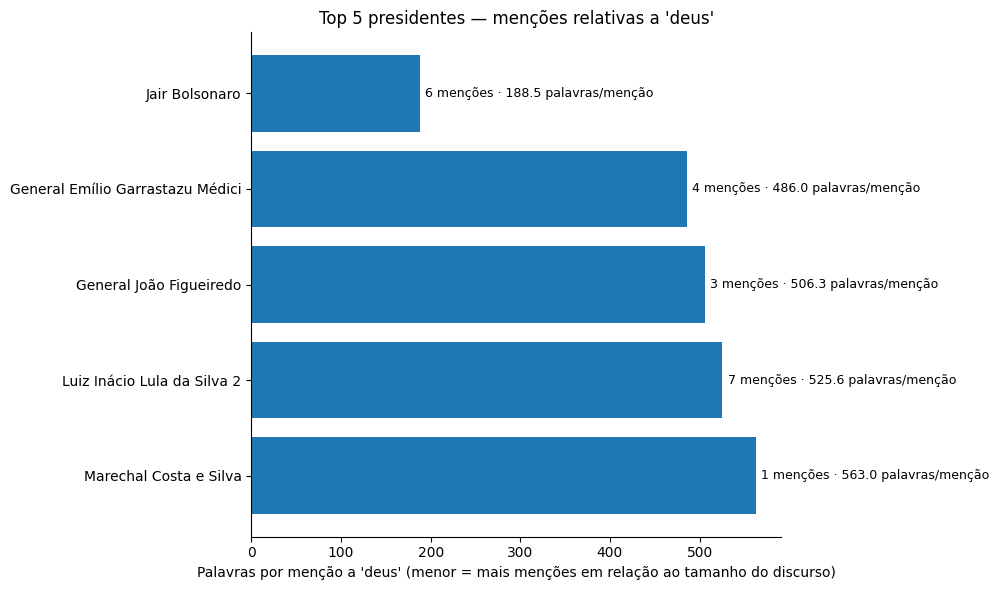

In [55]:

# preparar plot
def plot_relativo(df, palavra):
    col_ratio = f'palavras_por_{palavra}'
    col_total = f'total_{palavra}'

    y_pos = range(len(df))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.barh(y_pos, df[col_ratio])
    ax.set_yticks(y_pos)
    ax.set_yticklabels(df['presidente'])
    ax.invert_yaxis()

    ax.set_xlabel(f"Palavras por menção a '{palavra}' (menor = mais menções em relação ao tamanho do discurso)")
    ax.set_title(f"Top {len(df)} presidentes — menções relativas a '{palavra}'")

    # anotações
    max_val = df[col_ratio].max()
    for i, row in enumerate(df.itertuples()):
        valor = getattr(row, col_ratio)
        total = getattr(row, col_total)

        ax.text( valor + max_val * 0.01, i, f"{int(total)} menções · {valor:.1f} palavras/menção", va='center', fontsize=9)

    # estética
    ax.spines['right'].set_visible(False)
    ax.spines['top'].set_visible(False)

    plt.tight_layout()
    plt.show()

plot_relativo(df_deus[:5], "deus")

# A palavra "Democracia"
Enquanto o uso do termo “Deus” expressa a relação entre política e religiosidade, a recorrência da palavra “democracia” revela como os presidentes constroem discursivamente a legitimidade do regime e do próprio mandato ao longo da história republicana.

In [53]:
query = """
SELECT presidente, COUNT(*) AS total_democracia
FROM (
    SELECT
        presidente,
        unnest(string_to_array(lower(regexp_replace(par, '[^a-zA-Záéíóúàèìòùâêîôûãõçü ]', '', 'g')),' ')
        ) AS palavra
    FROM speeches
) AS t
WHERE palavra = 'democracia'
GROUP BY presidente
ORDER BY total_democracia DESC;
"""

df_democracia = pd.read_sql(query, engine)

df_democracia['total_palavras'] = df_democracia['presidente'].map(df_tamanho.set_index('presidente')['total_palavras'])

# Criar a razão
df_democracia['palavras_por_democracia'] = df_democracia['total_palavras'] / df_democracia['total_democracia']

df_democracia = df_democracia.sort_values('palavras_por_democracia', ascending=True)

df_democracia[['presidente', 'total_democracia', 'total_palavras', 'palavras_por_democracia']].head(20)

df_democracia.head(20)

,presidente,total_democracia,total_palavras,palavras_por_democracia
1,Fernando Henrique Cardoso 2,9,2664,296.000000
11,Jânio Quadros,2,642,321.000000
2,Luiz Inácio Lula da Silva 3,8,2916,364.500000
12,João Goulart,2,918,459.000000
13,Marechal Castelo Branco,2,1015,507.500000
0,Fernando Collor de Mello,11,5859,532.636364
10,Jair Bolsonaro,2,1131,565.500000
3,José Sarney,5,2919,583.800000
19,Itamar Franco,1,602,602.000000
7,General Emílio Garrastazu Médici,3,1944,648.000000


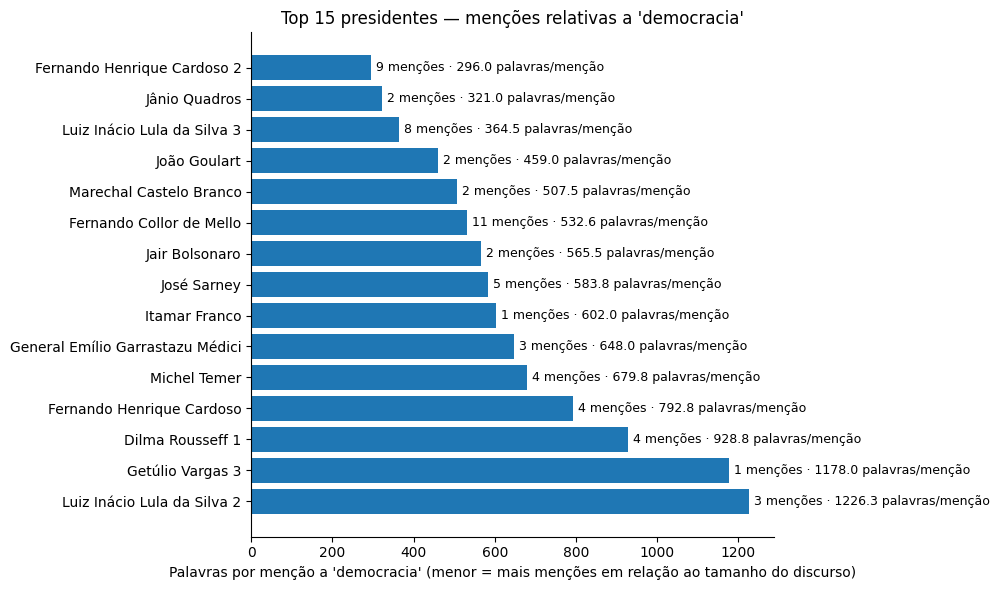

In [56]:
plot_relativo(df_democracia[:15], "democracia")